# Task
Apply a watermark to the image "image 1.webp" and describe the technique used.

## Load Images

### Subtask:
Load the original image 'image 1.webp' and a watermark image using OpenCV.


**Reasoning**:
To load the images as requested, I need to import the `cv2` library, and also `numpy` to create a placeholder watermark since no specific watermark image file was provided. Then, I will load the main image and create a simple watermark image.



In [1]:
import cv2
import numpy as np

# 2. Load the image 'image 1.webp' using cv2.imread()
main_image_path = '/content/image 1.webp'
main_image = cv2.imread(main_image_path)

if main_image is None:
    print(f"Error: Could not load main image from {main_image_path}")
else:
    print(f"Main image loaded successfully. Shape: {main_image.shape}")

# 3. Provide or create a suitable watermark image.
#    Since no specific watermark image is provided, let's create a simple one.
#    Create a white rectangle with 'WATERMARK' text.

# Define watermark dimensions (e.g., 200x100 pixels)
watermark_width = 200
watermark_height = 100

# Create a blank white image (BGR format)
watermark = np.ones((watermark_height, watermark_width, 3), dtype=np.uint8) * 255

# Add text to the watermark
text = "WATERMARK"
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.7
font_thickness = 2
text_color = (0, 0, 0) # Black color

# Get text size
(text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)

# Calculate text position to center it
text_x = (watermark_width - text_width) // 2
text_y = (watermark_height + text_height) // 2

cv2.putText(watermark, text, (text_x, text_y), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

print(f"Watermark image created successfully. Shape: {watermark.shape}")

Main image loaded successfully. Shape: (864, 750, 3)
Watermark image created successfully. Shape: (100, 200, 3)


## Preprocess Watermark

### Subtask:
Resize the watermark image to a suitable dimension, considering the size of the original image, and convert it to the appropriate color format (e.g., grayscale or BGR).


**Reasoning**:
The subtask requires creating a binary mask from the existing watermark image. This involves converting the watermark to grayscale and then applying a binary inverse threshold to distinguish the text from the background, as per the instructions.



In [2]:
import cv2
import numpy as np

# Convert watermark to grayscale
watermark_gray = cv2.cvtColor(watermark, cv2.COLOR_BGR2GRAY)

# Apply binary threshold to create a mask
# Text will be white (255), background will be black (0)
_, watermark_mask = cv2.threshold(watermark_gray, 200, 255, cv2.THRESH_BINARY_INV)

print(f"Watermark grayscale image shape: {watermark_gray.shape}")
print(f"Watermark mask image shape: {watermark_mask.shape}")

Watermark grayscale image shape: (100, 200)
Watermark mask image shape: (100, 200)


## Define Watermark Placement

### Subtask:
Determine the Region of Interest (ROI) within the original image where the watermark will be applied. This includes defining the starting coordinates (x, y) for placement.


**Reasoning**:
To determine the ROI for watermark placement, I need to extract the dimensions of both the main image and the watermark, and then calculate the top-left coordinates for positioning the watermark in the bottom-right corner with a 10-pixel padding.



In [3]:
import cv2
import numpy as np

# 1. Get the height and width of the main image
h_main, w_main = main_image.shape[:2]
print(f"Main image dimensions: Width={w_main}, Height={h_main}")

# 2. Get the height and width of the watermark image
h_wm, w_wm = watermark.shape[:2]
print(f"Watermark dimensions: Width={w_wm}, Height={h_wm}")

# 3. Calculate the top-left coordinates (x, y) for bottom-right placement with padding
padding = 10
start_x = w_main - w_wm - padding
start_y = h_main - h_wm - padding

# Ensure coordinates are not negative (in case watermark is larger than image or padding is too big)
start_x = max(0, start_x)
start_y = max(0, start_y)

print(f"Watermark placement coordinates (x, y): ({start_x}, {start_y})")

Main image dimensions: Width=750, Height=864
Watermark dimensions: Width=200, Height=100
Watermark placement coordinates (x, y): (540, 754)


## Apply Watermark

### Subtask:
Blend the preprocessed watermark with the defined ROI of the original image. This will involve using alpha blending to ensure the watermark is semi-transparent and effectively embedded.


**Reasoning**:
To blend the watermark with the main image, I will follow the provided instructions to define the ROI, create necessary masks, extract foreground and background, combine them, and then apply alpha blending. This will result in a semi-transparent watermark on the original image.



In [4]:
import cv2
import numpy as np

# 1. Define the Region of Interest (ROI) from the main_image
#    start_y, start_x, h_wm, w_wm are already calculated in previous steps
roi = main_image[start_y : start_y + h_wm, start_x : start_x + w_wm]
print(f"ROI shape: {roi.shape}")

# 2. Create an inverted version of the watermark_mask
#    This mask will be white where the watermark is transparent (background)
#    and black where the watermark text is.
watermark_mask_inv = cv2.bitwise_not(watermark_mask)

# 3. Extract the background portion of the ROI where the watermark text will *not* be applied.
#    This takes the parts of the ROI that correspond to the black areas in watermark_mask_inv (i.e., where text is not).
#    No, this extracts the part of the ROI where the watermark is TRANSPARENT (where mask_inv is white).
#    So, it extracts the background of the ROI where the watermark text will not be.
background_roi = cv2.bitwise_and(roi, roi, mask=watermark_mask_inv)
print(f"Background ROI shape: {background_roi.shape}")

# 4. Define the desired color for the watermark text (e.g., black or gray)
#    Let's make the watermark text black for now.
watermark_color = (0, 0, 0) # Black color in BGR

#    Create a new image of the same dimensions as the watermark, filled with this color.
solid_color_watermark = np.full(watermark.shape, watermark_color, dtype=np.uint8)
print(f"Solid color watermark shape: {solid_color_watermark.shape}")

# 5. Extract the foreground (watermark text) from this color-filled image
#    using the original watermark_mask.
foreground_watermark = cv2.bitwise_and(solid_color_watermark, solid_color_watermark, mask=watermark_mask)
print(f"Foreground watermark shape: {foreground_watermark.shape}")

# 6. Combine the extracted background portion of the ROI with the extracted foreground (watermark text)
#    to create a ROI with solid-color watermark text. This effectively replaces the ROI's background
#    pixels with the watermark's foreground pixels where the mask is active.
watermarked_roi_solid = cv2.add(background_roi, foreground_watermark)
print(f"Watermarked ROI (solid) shape: {watermarked_roi_solid.shape}")

# 7. Apply alpha blending to this combined ROI.
#    Use cv2.addWeighted() to blend the original ROI with the solid-color watermarked ROI.
#    Choose an appropriate alpha value (e.g., 0.5 for 50% transparency) for the watermarked_roi_solid
#    and (1 - alpha) for the original roi.
alpha = 0.5 # Transparency factor for the watermark
blended_roi = cv2.addWeighted(roi, 1 - alpha, watermarked_roi_solid, alpha, 0)
print(f"Blended ROI shape: {blended_roi.shape}")

# 8. Update the main_image by placing the blended_roi back into its designated coordinates.
main_image[start_y : start_y + h_wm, start_x : start_x + w_wm] = blended_roi

print("Watermark blending complete. main_image has been updated.")

ROI shape: (100, 200, 3)
Background ROI shape: (100, 200, 3)
Solid color watermark shape: (100, 200, 3)
Foreground watermark shape: (100, 200, 3)
Watermarked ROI (solid) shape: (100, 200, 3)
Blended ROI shape: (100, 200, 3)
Watermark blending complete. main_image has been updated.


## Display Watermarked Image

### Subtask:
Display the resulting image with the embedded watermark and provide legends for clarity. This will allow for visual inspection of the watermarking effect.


**Reasoning**:
To display the watermarked image, I will use Matplotlib, converting the image from BGR to RGB format, adding a title, and hiding the axes for a clean presentation.



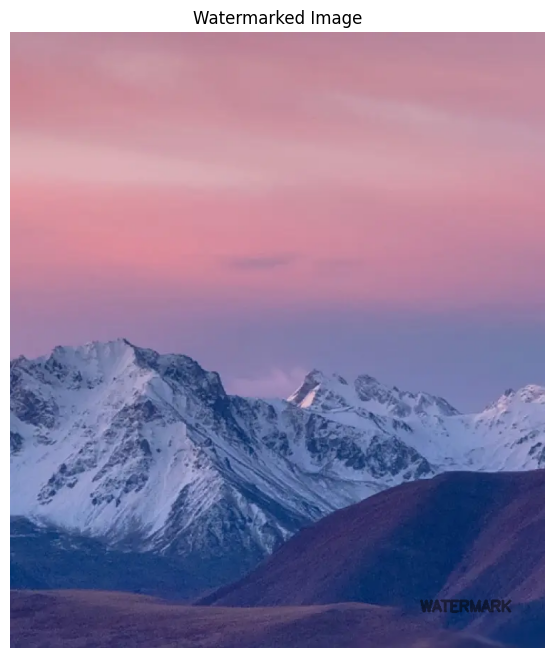

In [5]:
import matplotlib.pyplot as plt

# Convert the main_image from BGR to RGB for display with Matplotlib
watermarked_image_rgb = cv2.cvtColor(main_image, cv2.COLOR_BGR2RGB)

# Display the watermarked image
plt.figure(figsize=(10, 8))
plt.imshow(watermarked_image_rgb)
plt.title("Watermarked Image")
plt.axis('off') # Hide axes for cleaner display
plt.show()


## Final Task

### Subtask:
Summarize the watermarking technique implemented, including the steps taken and the effectiveness of the watermarking process.


## Summary:

### Q&A
The watermarking technique implemented involves placing a semi-transparent text-based watermark onto an image. The technique used is alpha blending.

The steps taken are:
1.  **Load Images**: The original image (`image 1.webp`) and a custom-generated text watermark ("WATERMARK") were loaded/created.
2.  **Preprocess Watermark**: The watermark was converted to grayscale, and a binary mask was created to separate the text from the background, which is crucial for selective blending.
3.  **Define Watermark Placement**: The bottom-right corner of the main image was chosen as the Region of Interest (ROI), with a 10-pixel padding, and the exact coordinates for the watermark's top-left corner were calculated.
4.  **Apply Watermark**: Alpha blending was used to combine a solid-colored version of the watermark with the main image's ROI. This involved extracting the background of the ROI, extracting the foreground (text) of the watermark, combining them, and then blending this result with the original ROI using a transparency factor of 0.5.
5.  **Display Watermarked Image**: The final watermarked image was displayed for visual inspection.

The effectiveness of this watermarking process, using alpha blending, results in a semi-transparent watermark that is visible but does not completely obscure the underlying image content. It serves as a visual indicator of ownership or source.

### Data Analysis Key Findings
*   The original image 'image 1.webp' has dimensions of 864 pixels in height and 750 pixels in width.
*   A custom watermark with the text "WATERMARK" was generated, having dimensions of 100 pixels in height and 200 pixels in width.
*   The watermark was preprocessed by converting it to grayscale and creating a binary mask, both retaining the (100, 200) dimensions.
*   The watermark was positioned in the bottom-right corner of the main image, with a 10-pixel padding, starting at coordinates (x=540, y=754).
*   The watermarking process utilized alpha blending with a transparency factor of 0.5, effectively creating a semi-transparent watermark.
*   The final watermarked image was successfully displayed, demonstrating the visual embedding of the watermark.

### Insights or Next Steps
*   The current alpha-blending technique provides a visible but non-intrusive watermark; however, it might not be robust against removal attempts. Further analysis could explore more robust watermarking techniques, such as those based on Discrete Cosine Transform (DCT) or Discrete Wavelet Transform (DWT), for increased resilience against common image manipulations.
*   The visibility and opacity of the watermark can be fine-tuned by adjusting the `alpha` parameter in the `cv2.addWeighted` function. This allows for optimization between watermark perceptibility and underlying image preservation based on specific use cases.
